# Staggered Difference-in-Differences Analysis

## Overview

This notebook estimates the main staggered Difference-in-Differences (DiD) analysis for the hospital merger project.

The main outcome is `log(cost_per_discharge)`.

Parallel-trend diagnostics are handled in the separate parallel-trend notebook. Here, never-treated hospitals stay in the sample and serve as controls throughout the estimation.

## Design Context

Hospitals experience merger exposure in different years, so treatment timing is staggered across units.

The event-study specification compares treated hospitals across relative event time against never-treated hospitals observed in the same calendar years, while controlling for fixed differences across hospitals and common year shocks.

## Objectives

- Build a clean model-ready hospital-year sample
- Define treatment timing relative to merger year
- Create event-study indicators with `event_time = -1` as the omitted reference period
- Estimate the main staggered event-study model with hospital and year fixed effects
- Cluster standard errors at the hospital level
- Summarize coefficients in log points and approximate percent terms
- Visualize event-time estimates with confidence intervals

## Dataset Description

The notebook uses `01_data/hospital_analysis.csv`.

Core variables include `PRVDR_NUM`, `fiscal_year`, `treated`, `merger_year`, `cost_per_discharge`, `total_discharges`, and `PRVDR_CTRL_TYPE_CD`.

The analysis outcome is transformed as `log_cost = log(cost_per_discharge)`.

## Outcome

By the end of this notebook, we get the main staggered event-study estimates, a coefficient table, and an event-time plot saved to the output figures folder.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

In [2]:
data_path = Path("../01_data/hospital_analysis.csv")
output_dir = Path("../04_outputs/figures")
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

print("df.shape:", df.shape)
df.head()

df.shape: (55805, 30)


,fiscal_year,RPT_REC_NUM,PRVDR_NUM,NPI,FY_BGN_DT,FY_END_DT,PRVDR_CTRL_TYPE_CD,total_operating_costs,net_patient_revenue,total_charges,...,merger_of_equals,bankruptcy,system_exit,system_split,system_id_yr,any_merger,merger_year,treated,years_to_merger,post_merger
0,2011,1022,271326,NaN,01/01/2011,12/31/2011,2,8661723.0,10224482.0,9125.0,...,0,0,0,0,2246.0,0,NaN,0,NaN,0
1,2011,1501,13025,NaN,01/01/2011,12/31/2011,4,39554420.0,28191835.0,36500.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
2,2011,1504,103037,NaN,01/01/2011,12/31/2011,4,20242022.0,15733902.0,25550.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
3,2011,1506,103042,NaN,01/01/2011,12/31/2011,4,26136744.0,21786350.0,29200.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
4,2011,1507,141990,NaN,01/01/2011,12/31/2011,1,116445.0,486669.0,6205.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0


## 2. Clean data and create log_cost

In [4]:
# Keep only the columns needed for analysis.
keep_cols = [
    "PRVDR_NUM",
    "fiscal_year",
    "treated",
    "merger_year",
    "cost_per_discharge",
    "total_discharges",
    "PRVDR_CTRL_TYPE_CD",
]

df2 = df[keep_cols].copy()

# Drop missing values only for model-required columns (not merger_year).
required_cols = [
    "PRVDR_NUM",
    "fiscal_year",
    "treated",
    "cost_per_discharge",
    "total_discharges",
    "PRVDR_CTRL_TYPE_CD",
]

df2 = df2.dropna(subset=required_cols)

# Keep treated values 0/1 only and positive costs only.
df2 = df2[df2["treated"].isin([0, 1])].copy()
df2 = df2[df2["cost_per_discharge"] > 0].copy()

# Convert to integer types for key model variables.
df2["treated"] = df2["treated"].astype(int)
df2["fiscal_year"] = df2["fiscal_year"].astype(int)
df2["PRVDR_CTRL_TYPE_CD"] = df2["PRVDR_CTRL_TYPE_CD"].astype(int)

# Create log outcome.
df2["log_cost"] = np.log(df2["cost_per_discharge"])

In [5]:
# Summary checks after cleaning.
unique_hospitals = df2["PRVDR_NUM"].nunique()

treated_hospitals = df2.loc[df2["treated"] == 1, "PRVDR_NUM"].nunique()
never_treated_hospitals = df2.loc[df2["treated"] == 0, "PRVDR_NUM"].nunique()

treated_missing_merger_year = (
    (df2["treated"] == 1) & (df2["merger_year"].isna())
).sum()
never_treated_missing_merger_year = (
    (df2["treated"] == 0) & (df2["merger_year"].isna())
).sum()

print("Cleaned data shape:", df2.shape)
print("Unique hospitals:", unique_hospitals)
print("Treated hospitals:", treated_hospitals)
print("Never-treated hospitals:", never_treated_hospitals)
print("Treated rows with missing merger_year:", treated_missing_merger_year)
print("Never-treated rows with missing merger_year:", never_treated_missing_merger_year)

df2.head()

Cleaned data shape: (53354, 8)
Unique hospitals: 6461
Treated hospitals: 1242
Never-treated hospitals: 5219
Treated rows with missing merger_year: 0
Never-treated rows with missing merger_year: 42054


,PRVDR_NUM,fiscal_year,treated,merger_year,cost_per_discharge,total_discharges,PRVDR_CTRL_TYPE_CD,log_cost
0,271326,2011,0,NaN,55882.083871,155.0,2,10.930999
1,13025,2011,0,NaN,16549.966527,2390.0,4,9.714139
2,103037,2011,0,NaN,14775.198540,1370.0,4,9.600705
3,103042,2011,0,NaN,17482.771906,1495.0,4,9.768971
4,141990,2011,0,NaN,10585.909091,11.0,1,9.267279


## 3. Create treatment variables

In [6]:
# Create treatment-timing variables.
# event_time is defined relative to merger year and can be missing for never-treated hospitals.
df2["event_time"] = df2["fiscal_year"] - df2["merger_year"]

# post_treatment is 1 only for treated hospitals in merger year or later; otherwise 0.
df2["post_treatment"] = (
    (df2["treated"] == 1) & (df2["fiscal_year"] >= df2["merger_year"])
).astype(int)

In [7]:
# Simple checks.
post_1_rows = (df2["post_treatment"] == 1).sum()
post_0_rows = (df2["post_treatment"] == 0).sum()

treated_hospitals_step3 = df2.loc[df2["treated"] == 1, "PRVDR_NUM"].nunique()
never_treated_hospitals_step3 = df2.loc[df2["treated"] == 0, "PRVDR_NUM"].nunique()

print("Rows with post_treatment = 1:", post_1_rows)
print("Rows with post_treatment = 0:", post_0_rows)
print("Treated hospitals:", treated_hospitals_step3)
print("Never-treated hospitals:", never_treated_hospitals_step3)

# Show a small preview of key treatment variables.
show_cols = [
    "PRVDR_NUM",
    "fiscal_year",
    "treated",
    "merger_year",
    "event_time",
    "post_treatment",
]

df2[show_cols].head(12)

Rows with post_treatment = 1: 6555
Rows with post_treatment = 0: 46799
Treated hospitals: 1242
Never-treated hospitals: 5219


,PRVDR_NUM,fiscal_year,treated,merger_year,event_time,post_treatment
0,271326,2011,0,NaN,NaN,0
1,13025,2011,0,NaN,NaN,0
2,103037,2011,0,NaN,NaN,0
3,103042,2011,0,NaN,NaN,0
4,141990,2011,0,NaN,NaN,0
5,143028,2011,0,NaN,NaN,0
6,313029,2011,0,NaN,NaN,0
7,453059,2011,0,NaN,NaN,0
8,493028,2011,0,NaN,NaN,0
9,513026,2011,0,NaN,NaN,0


## 4. Create event-study indicators

This notebook uses a staggered event-study specification instead of a simple TWFE `post_treatment` model.

Event time is measured relative to each treated hospital's merger year.

Event time `-1` is the omitted reference period.

Never-treated hospitals remain in the data as controls, but they do not receive event-time indicators.

In [8]:
# Define the event-study window and omit event_time = -1 as the reference period.
event_window = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
event_terms = [-4, -3, -2, 0, 1, 2, 3, 4]

# Map each event time to its indicator column name.
event_map = {
    -4: "ev_m4",
    -3: "ev_m3",
    -2: "ev_m2",
    0: "ev_0",
    1: "ev_1",
    2: "ev_2",
    3: "ev_3",
    4: "ev_4",
}

# Create event-time indicators for treated hospitals only.
for k in event_terms:
    col = event_map[k]
    df2[col] = ((df2["treated"] == 1) & (df2["event_time"] == k)).astype(int)

# Collect event-study indicator column names.
event_cols = [event_map[k] for k in event_terms]

print("Event-study window:", event_window)
print("Omitted reference period:", -1)
print("Event-study indicator columns:", event_cols)

Event-study window: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
Omitted reference period: -1
Event-study indicator columns: ['ev_m4', 'ev_m3', 'ev_m2', 'ev_0', 'ev_1', 'ev_2', 'ev_3', 'ev_4']


In [9]:
# Count how many rows are equal to 1 for each event-study indicator.
event_count_table = df2[event_cols].sum().reset_index()
event_count_table.columns = ["event_indicator", "rows_with_1"]

event_count_table

,event_indicator,rows_with_1
0,ev_m4,605
1,ev_m3,787
2,ev_m2,1006
3,ev_0,1433
4,ev_1,1214
5,ev_2,997
6,ev_3,879
7,ev_4,715


## 5. Main staggered event-study regression

We estimate the main staggered event-study model:

\[
\text{log\_cost}_{it} = \sum_{k \in K} \beta_k \cdot 1(\text{event\_time}_{it}=k) + \alpha_i + \gamma_t + \varepsilon_{it}
\]

- Event time `-1` is the omitted reference period.
- The event-time coefficients show differences in `log(cost_per_discharge)` relative to one year before merger.
- Never-treated hospitals remain in the model as controls.
- Hospital fixed effects control for time-invariant hospital differences.
- Fiscal year fixed effects control for common year shocks.
- Standard errors are clustered at the hospital level.

In [10]:
# Use the cleaned analysis data with event-study indicators.
df = df2.copy()

# Define the event-study outcome.
y_event = df["log_cost"].astype(float)

# Build regression matrix: event-study indicators + hospital FE + year FE.
hospital_fe_event = pd.get_dummies(
    df["PRVDR_NUM"], prefix="hosp", drop_first=True, dtype=float
)
year_fe_event = pd.get_dummies(
    df["fiscal_year"], prefix="year", drop_first=True, dtype=float
)

X_event = pd.concat([df[event_cols], hospital_fe_event, year_fe_event], axis=1)
X_event = add_constant(X_event, has_constant="add")

# Estimate event-study model with clustered standard errors.
event_model = OLS(y_event, X_event).fit(
    cov_type="cluster", cov_kwds={"groups": df["PRVDR_NUM"]}
)

In [11]:
# Build event-study coefficient table.
event_time_lookup = {v: k for k, v in event_map.items()}

event_results = pd.DataFrame(
    {
        "event_col": event_cols,
        "event_time": [event_time_lookup[c] for c in event_cols],
        "estimate": [float(event_model.params[c]) for c in event_cols],
        "standard_error": [float(event_model.bse[c]) for c in event_cols],
        "p_value": [float(event_model.pvalues[c]) for c in event_cols],
    }
)

conf_int = event_model.conf_int()
event_results["ci_95_low"] = [float(conf_int.loc[c, 0]) for c in event_cols]
event_results["ci_95_high"] = [float(conf_int.loc[c, 1]) for c in event_cols]
event_results["approximate_percent_change"] = 100 * (
    np.exp(event_results["estimate"]) - 1
)

event_results = event_results[
    [
        "event_time",
        "estimate",
        "standard_error",
        "ci_95_low",
        "ci_95_high",
        "p_value",
        "approximate_percent_change",
    ]
].sort_values("event_time")

event_results.round(4)

,event_time,estimate,standard_error,ci_95_low,ci_95_high,p_value,approximate_percent_change
0,-4,-0.0058,0.0092,-0.0240,0.0123,0.5282,-0.5816
1,-3,-0.0015,0.0095,-0.0201,0.0171,0.8763,-0.1479
2,-2,-0.0116,0.0094,-0.0300,0.0067,0.2147,-1.1569
3,0,-0.0298,0.0122,-0.0538,-0.0059,0.0147,-2.9376
4,1,-0.0190,0.0122,-0.0429,0.0049,0.1199,-1.8806
5,2,-0.0154,0.0154,-0.0456,0.0147,0.3163,-1.5309
6,3,-0.0088,0.0143,-0.0368,0.0192,0.5394,-0.8735
7,4,-0.0053,0.0140,-0.0328,0.0222,0.7067,-0.5268


## 6. Event-study coefficient plot

This plot shows event-time estimates relative to `event_time = -1`.

Event time `-1` is omitted as the reference period.

The points are regression estimates from the event-study model.

The vertical bars show 95% confidence intervals.

The red vertical line at `event_time = 0` marks the merger year.

Saved: ../04_outputs/figures/staggered_did_event_study.png


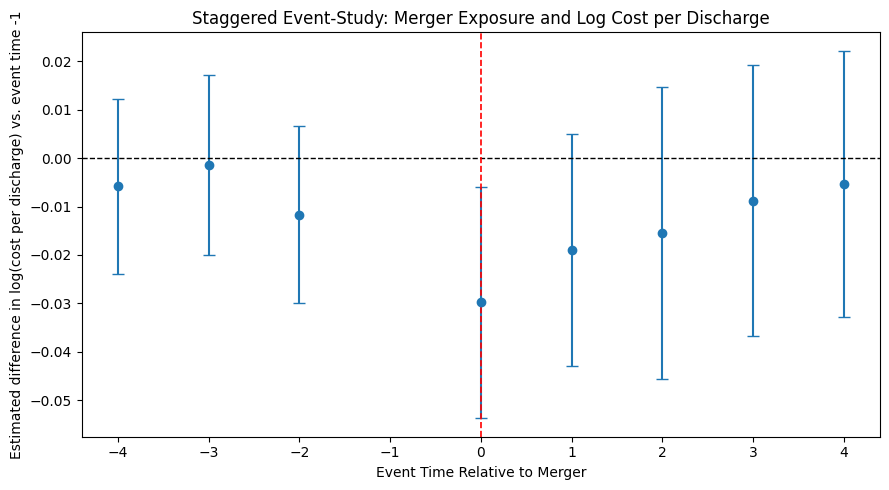

In [ ]:
# Use the event-study coefficient table from Step 5.
plot_df = event_results.sort_values("event_time").copy()

x_vals = plot_df["event_time"].to_numpy()
y_vals = plot_df["estimate"].to_numpy()
ci_low = plot_df["ci_95_low"].to_numpy()
ci_high = plot_df["ci_95_high"].to_numpy()

y_err = np.vstack([y_vals - ci_low, ci_high - y_vals])

# Include all event times in the table and add -1 as the reference tick.
x_ticks = sorted(set(plot_df["event_time"].tolist() + [-1]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    x_vals,
    y_vals,
    yerr=y_err,
    fmt="o",
    color="tab:blue",
    ecolor="tab:blue",
    capsize=4,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2)

ax.set_title("Staggered Event-Study: Merger Exposure and Log Cost per Discharge")
ax.set_xlabel("Event Time Relative to Merger")
ax.set_ylabel("Estimated difference in log(cost per discharge) vs. event time -1")
ax.set_xticks(x_ticks)

fig.tight_layout()

plot_dir = output_dir / "03_staggered_DiD"
plot_dir.mkdir(parents=True, exist_ok=True)
plot_path = plot_dir / "staggered_did_event_study.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")

print("Saved:", plot_path)
plt.show()

# Interpretation
The event-study coefficient table shows that the pre-treatment estimates at event times -4, -3, and -2 are small and not statistically significant. This is consistent with the separate parallel-trend diagnostic. The estimate at event time 0 is negative and statistically significant, suggesting that log(cost_per_discharge) is about 2.9% lower in the merger year relative to event time -1. However, the post-treatment estimates for event times 1 through 4 are not statistically significant, so the event-study does not provide strong evidence of a sustained post-merger change in cost per discharge.